Please run the cell below to import libraries needed for this HW. Please use the autograd numpy, otherwise you will have issues. 

In [72]:
import autograd.numpy as np
from autograd import grad 
import matplotlib.pyplot as plt
%matplotlib inline


Q1) [10 points] Implement the linear regression model discussed in class below. The function (called model) takes in an array of data points, x , and an array of weights, w, and returns a vector y containing the linear combination for each of the data points. This is the linear model we have discussed in class. You can assume each data point in x only has one feature.  The length of the vector being returned should be the same as x.


In [73]:
def model(x,w):
    #your code here
    y = w[0] + np.dot(np.transpose(x),w[1:])
    y = np.transpose(y)
    return y

Q2) [10 ponts] Implement the least squares function discussed in class below. The function should take in an array of weights, w, an array of x's and an array of ys. It should use the model function implemented above and return a float indicating the total cost.

In [74]:
def least_squares(w,x,y):    
    #your code here
    p = y.size # get number of points
    squares = (model(x,w) - y)**2 
    cost = np.sum(squares)/p  # cost
    return cost

Q3) [5 point] This one is a freebie from HW1. Copy and paste your gradient descent function here. Specifically, the one that takes in the cost function as input and return the weight and cost history. We will be using a fixed alpha for this HW. The only difference is that this function should now also take in as input an array of x and ys, corresponding to our data. The w,x, and y are given as inputs to the cost funtion and its gradient.

In [75]:
def gradient_descent(g,alpha,max_its,w,x,y):
    #Your code here
    # get the gradient for the function
    gradient = grad(g)
    
    # build weight and cost history
    weight_history = []
    cost_history = []
    
    # iterate and keep track of weight and cost 
    for i in range(max_its):
        weight_history.append(w)
        cost_history.append(g(w,x,y))
        w = w - alpha*gradient(w,x,y) # descend in steepest direction
        
    return weight_history,cost_history

Q4) [1 points]  Run the code below to import a dataset. Then, plot a scatter plot of the data (x vs y).

Text(0, 0.5, 'y')

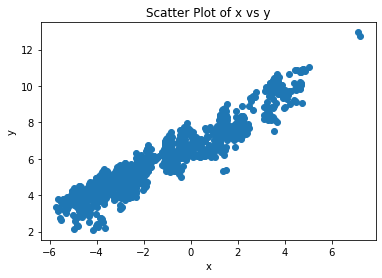

In [76]:
# import the dataset
csvname = 'kleibers_law_data.csv'
data = np.loadtxt(csvname,delimiter=',')
x = np.log(data[:-1,:])
y = np.log(data[-1:,:])
# make a scatter plot for x and y
plt.scatter(x,y)
plt.title('Scatter Plot of x vs y')
plt.xlabel('x')
plt.ylabel('y')

Q5) [5 points] Run the gradient descent function using the following parameters and plot the cost_history over the 1000 iterations

g = least_squares function you implemented

w = [w_0, w_1]  , where w_0 and w_1 are random numbers between -0.1 and 0.1

max_its=1000

alpha=0.01

Text(0, 0.5, 'Cost')

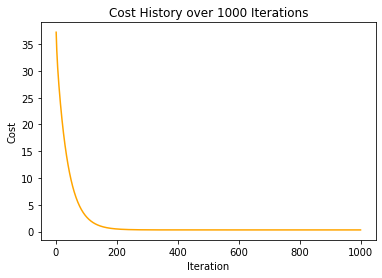

In [77]:
#Your code here
# generate random numbers
w = 2*np.random.uniform(size=2) - 1

#define parameters
max_its = 1000
alpha = 0.01

# run gradient descent and store weight and cost history
weight_hist,cost_hist = gradient_descent(least_squares,alpha,max_its,w,x,y)

# iteration list for plotting
i = [x+1 for x in range(max_its)]
# plot of cost over 1000 iterations
plt.plot(i,cost_hist, color = 'orange')
plt.title('Cost History over 1000 Iterations')
plt.xlabel('Iteration')
plt.ylabel('Cost')

Q6) [5 points] Use the learned weights from above (note that the "learned" weights are the ones with the lowest cost) to plot the learned line. You can use the linspace method (shown below) to generate a list of xs that you can use. You need to generate a y for each of the candidate xs using the learned weights. On the same figure, also plot the scatter plot from Q4. 


Text(0, 0.5, 'y')

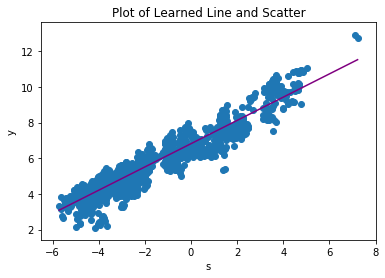

In [78]:
s = np.linspace(np.min(x),np.max(x))
#Your code here
ys = weight_hist[max_its-1][0] + weight_hist[max_its-1][1]*s
plt.plot(s,ys,color = 'purple')
plt.scatter(x,y)
plt.title('Plot of Learned Line and Scatter')
plt.xlabel('s')
plt.ylabel('y')

Q7) [1 points]  Run the code below to import a dataset. Then, plot a scatter plot of the data (x vs y).

Text(0, 0.5, 'y')

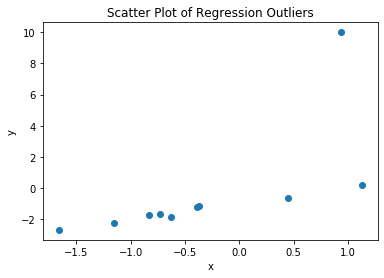

In [79]:
# load in dataset
data = np.loadtxt('regression_outliers.csv',delimiter = ',')
x = data[:-1,:]
y = data[-1:,:] 
#Your code here
plt.scatter(x,y)
plt.title('Scatter Plot of Regression Outliers')
plt.xlabel('x')
plt.ylabel('y')

Q8) [10 ponts] Implement the least absolute deviations function discussed in class. The function should take in an array of weights, w, an array of x's and an array of ys. It should use the model function implemented in Q1  and return a float indicating the total cost.

In [80]:
def least_absolute_deviations(w,x,y):
    #your code here
    p = y.size
    absolutes = abs(model(x,w) - y)
    cost = np.sum(absolutes)/p
    return cost

Q9) [5 points] Run the gradient descent function twice using the following parameters and plot the cost_history for both runs on the same plot. Make the plot for the first run blue and the plot for the second run red.

Run 1) 
g = least_squares function

w = [1.0,1.0]

max_its=100

alpha=0.1

Run 2) 
g = least_absoulte_deviations

w = [1.0,1.0]

max_its=100

alpha=0.1


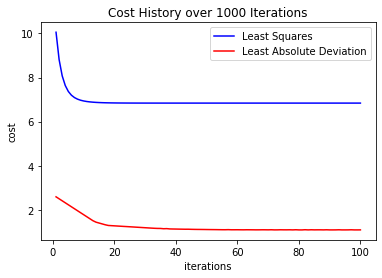

In [81]:
# parameters
w = np.array([1.0,1.0]) # starting weight
max_its = 100  # iterations
alpha = 0.1   # learning rate

# gradient 
run_1 = gradient_descent(least_squares,alpha,max_its,w,x,y)
run_2 = gradient_descent(least_absolute_deviations,alpha,max_its,w,x,y)

# iterations for plot
i = [x+1 for x in range(max_its)]

plt.plot(i,run_1[1],color = 'blue',label ='Least Squares')
plt.plot(i,run_2[1],color = 'red',label = 'Least Absolute Deviation')
plt.title('Cost History over 1000 Iterations')
plt.xlabel('iterations')
plt.ylabel('cost')
plt.legend()

Q10) [5 points] Use the learned weights from above to plot the two learned lines (use same colors as above). You can use the linspace method again to generate a list of xs that you can use. On the same figure, also plot the scatter plot from Q7. Which of these lines look like a better fit to you? 


Text(0, 0.5, 'y')

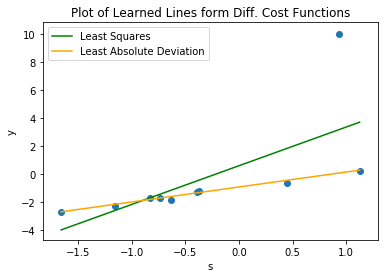

In [82]:
s = np.linspace(np.min(x),np.max(x))


l_weights_lse = run_1[0][max_its-1] # Get learned weights from 1st run
l_weights_lad = run_2[0][max_its-1] # Get learned weights from 2nd run

y_LSE = l_weights_lse[0] + l_weights_lse[1]*s # learned line from least squares
y_LAD = l_weights_lad[0] + l_weights_lad[1]*s # learned line from least absolute deviations

plt.plot(s,y_LSE, color = 'green',label ='Least Squares')
plt.plot(s,y_LAD,color = 'orange',label = 'Least Absolute Deviation')
plt.scatter(x,y)
plt.legend()
plt.title('Plot of Learned Lines form Diff. Cost Functions')
plt.xlabel('s')
plt.ylabel('y')

### Line of Better Fit
The line learned from the *Least absolute deviation* looks like a better fit to me

Q11) [6 points] Implement the mean squared error (MSE) and the mean absolute deviation functions from class. The functions should take in as input an array of actual ys and an array of predicted ys and return the prediction error.

In [83]:
def MSE(y_actual,y_pred):
    #Your code here
    p = y_actual.size
    error = np.sum((y_actual-y_pred)**2)/p
    return error

def MAD(y_actual,y_pred):
    #Your code here
    p = y_actual.size
    error = np.sum(abs(y_actual-y_pred))/p
    return error

Q12) [4 points] Use the functions above to report the MSE and MAD for the two models learned in Q9, using the x and y from Q7. You should have 4 values total, two for each model. Which model is doing better?

In [84]:
#Your code here
# for model with least squares cost function
y_LSE_pred = l_weights_lse[0] + l_weights_lse[1]*x
err_MSE = MSE(y,y_LSE_pred)
err_MAD = MAD(y,y_LSE_pred)
print('The MSE for Least Square Cost is    :',err_MSE)
print('The MAD for Least Square Cost is    :',err_MAD)

y_LAD_pred = l_weights_lad[0] + l_weights_lad[1]*x
err_MSE = MSE(y,y_LAD_pred)
err_MAD = MAD(y,y_LAD_pred)
print('The MSE for Least Abs. Dev. Cost is :',err_MSE)
print('The MAD for Least Abs. Dev. Cost is :',err_MAD)

The MSE for Least Square Cost is    : 6.84139430067187
The MAD for Least Square Cost is    : 1.6893703656370611
The MSE for Least Abs. Dev. Cost is : 9.85171705201565
The MAD for Least Abs. Dev. Cost is : 1.0924206937396541



Comparing the magnitudes of the errors make it looks like the model with the *Least Square cost function* is doing better. The numbers shown are inconclusive as to which model is doing better. Generally least abs. dev is more robust to outliers than least Squares. Therefore which model does better depends on the data we are looking at.

Q13) [6 points] Implement the L1 and L2 regularizers from class. Recall the regularizers take in input the weight vector and return a score based on the L1 or L2 norm of the weights

In [85]:
def L2_regularizer(w):
    L2_squared = np.dot(w.T,w)
    L2 = np.sqrt(L2_squared)
    return L2

def L1_regularizer(w):
    L1 = np.sum(abs(w))
    return L1

w = np.array([4,-3])
print(L2_regularizer(w))
print(L1_regularizer(w))

5.0
7


Q14) [12 points] Turn the least squares function implemented in Q2 into the Ridge (L2) and Lasso (L1) least squares (covered in class) using the functions implemented in Q13. Recall that $\lambda$ is used as a hyperparameter to specify the smoothness of the function learned (higher $\lambda$ leads to simpler and smoother functions whereas lower $\lambda$ leads to better fitting to the data. $\lambda=0$ is the same as non-regularized least-squares)

In [86]:
def ridge(w,x,y,lmbda):    
    #your code here
    L2_squared = (L2_regularizer(w))**2
    p = y.size
    squares = (model(x,w) - y)**2
    cost = np.sum(squares)/p + lmbda*L2_squared
    return cost

def lasso(w,x,y,lmbda):    
    #your code here
    p = y.size
    squares = (model(x,w) - y)**2
    cost = np.sum(squares)/p + lmbda*L1_regularizer(w)
    return cost

# The rest of the questions are for bonus points, but highly recommended

Q15) [4 points] The file 'poly_regr.csv'has 60 lines, each one corresponding to a data point (x,y). Read the fie and generate a scatter plot of the x vs y.

          x        y1
0  1.047198  1.065763
1  1.117011  1.006086
2  1.186824  0.695374
3  1.256637  0.949799
4  1.326450  1.063496


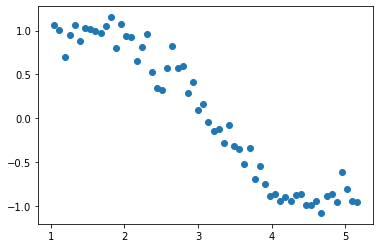

In [87]:
#Your code here
# read data into a Pandas Dataframe
import pandas as pd
data = pd.read_csv('poly_regr.csv',names=['x', 'y1'])
print(data.head())
x_column = data.iloc[:, 0]
y_column = data.iloc[:, 1]

#create an array using numpy for all values
x_array = np.array(x_column)
y_array = np.array(y_column)

plt.scatter(x_array,y_array)

Q16) [5 points] Modify each row of data from Q15 such that it contains not just x and y, but x, x^2, x^3, ..., x^9 and y. For instance, the row 2,5 (corresponding to the x and y) would turn into: 2,4,8, ..., 512, 5.  You will be using this data soon.

In [88]:
#Your code here
data['x^2'] = data.apply(lambda row: (row.x)**2, axis = 1) 
data['x^3'] = data.apply(lambda row: (row.x)**3, axis = 1)
data['x^4'] = data.apply(lambda row: (row.x)**4, axis = 1)
data['x^5'] = data.apply(lambda row: (row.x)**5, axis = 1)
data['x^6'] = data.apply(lambda row: (row.x)**6, axis = 1)
data['x^7'] = data.apply(lambda row: (row.x)**7, axis = 1)
data['x^8'] = data.apply(lambda row: (row.x)**8, axis = 1)
data['x^9'] = data.apply(lambda row: (row.x)**9, axis = 1)
data['y'] = data['y1']
data = data.drop('y1',axis = 1)
data.head()

,x,x^2,x^3,x^4,x^5,x^6,x^7,x^8,x^9,y
0,1.047198,1.096623,1.148381,1.202581,1.259340,1.318778,1.381021,1.446202,1.514459,1.065763
1,1.117011,1.247713,1.393709,1.556788,1.738948,1.942424,2.169709,2.423588,2.707173,1.006086
2,1.186824,1.408551,1.671702,1.984016,2.354677,2.794587,3.316683,3.936319,4.671717,0.695374
3,1.256637,1.579137,1.984402,2.493673,3.133642,3.937850,4.948448,6.218404,7.814277,0.949799
4,1.326450,1.759470,2.333850,3.095735,4.106339,5.446854,7.224981,9.583578,12.712139,1.063496


We are now going to using a well-known ML library called sklearn. If you do not have it installed, please do so using this instruction: https://scikit-learn.org/stable/install.html

sklearn comes with many models already implemented, below we import the standard linear regression, Ridge, and Lasso models from sklearn. We also import a method that can divide our data into train/test sets. Please run the cell below.

In [89]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso 
from sklearn.model_selection import train_test_split 

This library is very easy to use. We briefly go over it in the class but please use the API and user guide  ( https://scikit-learn.org) to learn exactly how to use this library.

For instance, learning a linear regression model using sklearn can be done in two lines:

linearModel = LinearRegression() 

linearModel.fit(x_train, y_train)

Q17) [2 points] Use the train_test_split to divide your modified data from Q16 into 80% train, 20% test. 

In [90]:
#Your code here
X= data.drop('y',axis=1)
y = data['y']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)


Q18) [15 points] Use sklearn to train 9 LinearRegression models from the modified data. The first should just be a first order polynomial (use x and y) , the second one should be quadratic (use x, x^2, and y), the third one should use x, x^2, x^3 and y and so on. Report the performance of each model on the test data (use sklearn's MSE implementation: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html). Note that the .predict method can be used to get the y_predictions for the test xs.

In [91]:
from sklearn.metrics import mean_squared_error
#Your code here
# train 9 models
# 9th order
#print(X_train.head())
LinReg_9 = LinearRegression()
LinReg_9.fit(X_train,y_train)

# 8th order
X_train = X_train.drop('x^9',axis =1)
#print(X_train.head())
LinReg_8 = LinearRegression()
LinReg_8.fit(X_train,y_train)

#7th Order
X_train = X_train.drop('x^8',axis =1)
#print(X_train.head())
LinReg_7 = LinearRegression()
LinReg_7.fit(X_train,y_train)

#6th Order
X_train = X_train.drop('x^7',axis =1)
#print(X_train.head())
LinReg_6 = LinearRegression()
LinReg_6.fit(X_train,y_train)

#5th Order
X_train = X_train.drop('x^6',axis =1)
#print(X_train.head())
LinReg_5 = LinearRegression()
LinReg_5.fit(X_train,y_train)

#4th Order
X_train = X_train.drop('x^5',axis =1)
#print(X_train.head())
LinReg_4 = LinearRegression()
LinReg_4.fit(X_train,y_train)

#3rd Order
X_train = X_train.drop('x^4',axis =1)
#print(X_train.head())
LinReg_3 = LinearRegression()
LinReg_3.fit(X_train,y_train)

#2nd Order
X_train = X_train.drop('x^3',axis =1)
#print(X_train.head())
LinReg_2 = LinearRegression()
LinReg_2.fit(X_train,y_train)

#1st Order
X_train = X_train.drop('x^2',axis =1)
#print(X_train.head())
LinReg_1 = LinearRegression()
LinReg_1.fit(X_train,y_train)

# visualize

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [92]:
# predictions and scores
y_pred9=LinReg_9.predict(X_test)
LinReg9_MSE = mean_squared_error(y_test, y_pred9)
print("Score for 9th Order :",LinReg9_MSE)
y_pred8=LinReg_8.predict(X_test.drop('x^9',axis =1))
LinReg8_MSE = mean_squared_error(y_test, y_pred8)
print("Score for 8th Order :",LinReg8_MSE)
y_pred7=LinReg_7.predict(X_test.drop(['x^8','x^9'],axis =1))
LinReg7_MSE = mean_squared_error(y_test, y_pred7)
print("Score for 7th Order :",LinReg7_MSE)
y_pred6=LinReg_6.predict(X_test.drop(['x^8','x^9','x^7'],axis =1))
LinReg6_MSE = mean_squared_error(y_test, y_pred6)
print("Score for 6th Order :",LinReg6_MSE)
y_pred5=LinReg_5.predict(X_test.drop(['x^8','x^9','x^7','x^6'],axis =1))
LinReg5_MSE = mean_squared_error(y_test, y_pred5)
print("Score for 5th Order :",LinReg5_MSE)
y_pred4=LinReg_4.predict(X_test.drop(['x^8','x^9','x^7','x^6','x^5'],axis =1))
LinReg4_MSE = mean_squared_error(y_test, y_pred4)
print("Score for 4th Order :",LinReg4_MSE)
y_pred3=LinReg_3.predict(X_test.drop(['x^8','x^9','x^7','x^6','x^5','x^4'],axis =1))
LinReg3_MSE = mean_squared_error(y_test, y_pred3)
print("Score for 3rd Order :",LinReg3_MSE)
y_pred2=LinReg_2.predict(X_test.drop(['x^8','x^9','x^7','x^6','x^5','x^4','x^3'],axis =1))
LinReg2_MSE = mean_squared_error(y_test, y_pred2)
print("Score for 2nd Order :",LinReg2_MSE)
y_pred1=LinReg_1.predict(X_test.drop(['x^8','x^9','x^7','x^6','x^5','x^4','x^3','x^2'],axis =1))
LinReg1_MSE = mean_squared_error(y_test, y_pred1)
print("Score for 2nd Order :",LinReg1_MSE)

Score for 9th Order : 0.019945802589908322
Score for 8th Order : 0.02404706502787934
Score for 7th Order : 0.025640845509683968
Score for 6th Order : 0.029832366648524625
Score for 5th Order : 0.02695521729814089
Score for 4th Order : 0.030048299489068783
Score for 3rd Order : 0.03153789350260342
Score for 2nd Order : 0.065777148424652
Score for 2nd Order : 0.06229381030630735


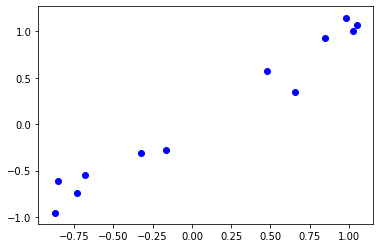

In [93]:
y_pred8=LinReg_8.predict(X_test.drop('x^9',axis =1))
plt.scatter(y_pred9,y_test,label = 'Model 8th degree', color = 'blue')

Q19) [20 points] Repeat Q18 but instead of LinearRegression, use the Ridge and Lasso functions. You can keep the default alpha (note that what we called lambda in the class, the hyperparameter for regularization, is called alpha in sklearn. It is the same thing). Of all the 27 models (9*3), which one seems to do the best?

In [94]:
#Your code here
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)
# 9th order
#print(X_train.head())
Rdg_9 = Ridge()
Rdg_9.fit(X_train,y_train)

# 8th order
X_train = X_train.drop('x^9',axis =1)
#print(X_train.head())
Rdg_8 = Ridge()
Rdg_8.fit(X_train,y_train)

#7th Order
X_train = X_train.drop('x^8',axis =1)
print(X_train.head())
Rdg_7 = Ridge()
Rdg_7.fit(X_train,y_train)

#6th Order
X_train = X_train.drop('x^7',axis =1)
print(X_train.head())
Rdg_6 = Ridge()
Rdg_6.fit(X_train,y_train)

#5th Order
X_train = X_train.drop('x^6',axis =1)
print(X_train.head())
Rdg_5 = Ridge()
Rdg_5.fit(X_train,y_train)

#4th Order
X_train = X_train.drop('x^5',axis =1)
print(X_train.head())
Rdg_4 = Ridge()
Rdg_4.fit(X_train,y_train)

#3rd Order
X_train = X_train.drop('x^4',axis =1)
print(X_train.head())
Rdg_3 = Ridge()
Rdg_3.fit(X_train,y_train)

#2nd Order
X_train = X_train.drop('x^3',axis =1)
print(X_train.head())
Rdg_2 = Ridge()
Rdg_2.fit(X_train,y_train)

#1st Order
X_train = X_train.drop('x^2',axis =1)
print(X_train.head())
Rdg_1 = Ridge()
Rdg_1.fit(X_train,y_train)



           x        x^2         x^3         x^4          x^5           x^6  \
4   1.326450   1.759470    2.333850    3.095735     4.106339      5.446854   
9   1.675516   2.807354    4.703767    7.881237    13.205140     22.125424   
53  4.747296  22.536815  106.988923  507.908039  2411.189580  11446.629600   
3   1.256637   1.579137    1.984402    2.493673     3.133642      3.937850   
19  2.373648   5.634204   13.373615   31.744252    75.349674    178.853587   

             x^7  
4       7.224981  
9      37.071504  
53  54340.533937  
3       4.948448  
19    424.535421  
           x        x^2         x^3         x^4          x^5           x^6
4   1.326450   1.759470    2.333850    3.095735     4.106339      5.446854
9   1.675516   2.807354    4.703767    7.881237    13.205140     22.125424
53  4.747296  22.536815  106.988923  507.908039  2411.189580  11446.629600
3   1.256637   1.579137    1.984402    2.493673     3.133642      3.937850
19  2.373648   5.634204   13.373615   31.7

Ridge(alpha=1.0, copy_X=True, fit_intercept=True, max_iter=None,
      normalize=False, random_state=None, solver='auto', tol=0.001)

In [95]:
### Report of Performance for Ridge Models
y_pred9=Rdg_9.predict(X_test)
Rdg9_MSE = mean_squared_error(y_test, y_pred9)
print("Score for 9th Order :",Rdg9_MSE)
y_pred8=Rdg_8.predict(X_test.drop('x^9',axis =1))
Rdg8_MSE = mean_squared_error(y_test, y_pred8)
print("Score for 8th Order :",Rdg8_MSE)
y_pred7=Rdg_7.predict(X_test.drop(['x^8','x^9'],axis =1))
Rdg7_MSE = mean_squared_error(y_test, y_pred7)
print("Score for 7th Order :",LinReg7_MSE)
y_pred6=Rdg_6.predict(X_test.drop(['x^8','x^9','x^7'],axis =1))
Rdg6_MSE = mean_squared_error(y_test, y_pred6)
print("Score for 6th Order :",LinReg6_MSE)
y_pred5=Rdg_5.predict(X_test.drop(['x^8','x^9','x^7','x^6'],axis =1))
Rdg5_MSE = mean_squared_error(y_test, y_pred5)
print("Score for 5th Order :",Rdg5_MSE)
y_pred4=Rdg_4.predict(X_test.drop(['x^8','x^9','x^7','x^6','x^5'],axis =1))
Rdg4_MSE = mean_squared_error(y_test, y_pred4)
print("Score for 4th Order :",Rdg4_MSE)
y_pred3=Rdg_3.predict(X_test.drop(['x^8','x^9','x^7','x^6','x^5','x^4'],axis =1))
Rdg3_MSE = mean_squared_error(y_test, y_pred3)
print("Score for 3rd Order :",Rdg3_MSE)
y_pred2=Rdg_2.predict(X_test.drop(['x^8','x^9','x^7','x^6','x^5','x^4','x^3'],axis =1))
Rdg2_MSE = mean_squared_error(y_test, y_pred2)
print("Score for 2nd Order :",Rdg2_MSE)
y_pred1=Rdg_1.predict(X_test.drop(['x^8','x^9','x^7','x^6','x^5','x^4','x^3','x^2'],axis =1))
Rdg1_MSE = mean_squared_error(y_test, y_pred1)
print("Score for 2nd Order :",Rdg1_MSE)

Score for 9th Order : 0.0293329523968543
Score for 8th Order : 0.029716497624615378
Score for 7th Order : 0.025640845509683968
Score for 6th Order : 0.029832366648524625
Score for 5th Order : 0.025999103479511648
Score for 4th Order : 0.026196297800085727
Score for 3rd Order : 0.0414945315453591
Score for 2nd Order : 0.05491897924963877
Score for 2nd Order : 0.053689382475204994


In [96]:
## Lasso
#Your code here
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)
# 9th order
#print(X_train.head())
Las_9 = Lasso()
Las_9.fit(X_train,y_train)

# 8th order
X_train = X_train.drop('x^9',axis =1)
#print(X_train.head())
Las_8 = Lasso()
Las_8.fit(X_train,y_train)

#7th Order
X_train = X_train.drop('x^8',axis =1)
print(X_train.head())
Las_7 = Lasso()
Las_7.fit(X_train,y_train)

#6th Order
X_train = X_train.drop('x^7',axis =1)
print(X_train.head())
Las_6 = Lasso()
Las_6.fit(X_train,y_train)

#5th Order
X_train = X_train.drop('x^6',axis =1)
print(X_train.head())
Las_5 = Lasso()
Las_5.fit(X_train,y_train)

#4th Order
X_train = X_train.drop('x^5',axis =1)
print(X_train.head())
Las_4 = Lasso()
Las_4.fit(X_train,y_train)

#3rd Order
X_train = X_train.drop('x^4',axis =1)
print(X_train.head())
Las_3 = Lasso()
Las_3.fit(X_train,y_train)

#2nd Order
X_train = X_train.drop('x^3',axis =1)
print(X_train.head())
Las_2 = Lasso()
Las_2.fit(X_train,y_train)

#1st Order
X_train = X_train.drop('x^2',axis =1)
print(X_train.head())
Las_1 = Lasso()
Las_1.fit(X_train,y_train)



           x        x^2        x^3         x^4         x^5          x^6  \
40  3.839724  14.743483  56.610911  217.370294  834.642013  3204.795266   
7   1.535890   2.358957   3.623098    5.564680    8.546734    13.126841   
17  2.234021   4.990852  11.149670   24.908602   55.646350   124.315140   
14  2.024582   4.098932   8.298624   16.801244   34.015494    68.867155   
23  2.652900   7.037881  18.670797   49.531767  131.402848   348.598676   

             x^7  
40  12305.530435  
7      20.161381  
17    277.722688  
14    139.427197  
23    924.797589  
           x        x^2        x^3         x^4         x^5          x^6
40  3.839724  14.743483  56.610911  217.370294  834.642013  3204.795266
7   1.535890   2.358957   3.623098    5.564680    8.546734    13.126841
17  2.234021   4.990852  11.149670   24.908602   55.646350   124.315140
14  2.024582   4.098932   8.298624   16.801244   34.015494    68.867155
23  2.652900   7.037881  18.670797   49.531767  131.402848   348.598676
   

/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_coordinate_descent.py:476: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.0919285481448338, tolerance: 0.002910433555095076
  positive)
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_coordinate_descent.py:476: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.90323251189662, tolerance: 0.002910433555095076
  positive)
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_coordinate_descent.py:476: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.311958606087534, tolerance: 0.002910433555095076
  positive)
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_coordinate_descent.py:476: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. 

Lasso(alpha=1.0, copy_X=True, fit_intercept=True, max_iter=1000,
      normalize=False, positive=False, precompute=False, random_state=None,
      selection='cyclic', tol=0.0001, warm_start=False)

In [97]:
# Report performance for Lasso
y_pred9=Las_9.predict(X_test)
Las9_MSE = mean_squared_error(y_test, y_pred9)
print("Score for 9th Order :",Las9_MSE)
y_pred8=Las_8.predict(X_test.drop('x^9',axis =1))
Las8_MSE = mean_squared_error(y_test, y_pred8)
print("Score for 8th Order :",Las8_MSE)
y_pred7=Las_7.predict(X_test.drop(['x^8','x^9'],axis =1))
Las7_MSE = mean_squared_error(y_test, y_pred7)
print("Score for 7th Order :",LinReg7_MSE)
y_pred6=Las_6.predict(X_test.drop(['x^8','x^9','x^7'],axis =1))
Las6_MSE = mean_squared_error(y_test, y_pred6)
print("Score for 6th Order :",Las6_MSE)
y_pred5=Las_5.predict(X_test.drop(['x^8','x^9','x^7','x^6'],axis =1))
Las5_MSE = mean_squared_error(y_test, y_pred5)
print("Score for 5th Order :",Las5_MSE)
y_pred4=Las_4.predict(X_test.drop(['x^8','x^9','x^7','x^6','x^5'],axis =1))
Las4_MSE = mean_squared_error(y_test, y_pred4)
print("Score for 4th Order :",Las4_MSE)
y_pred3=Las_3.predict(X_test.drop(['x^8','x^9','x^7','x^6','x^5','x^4'],axis =1))
Las3_MSE = mean_squared_error(y_test, y_pred3)
print("Score for 3rd Order :",Las3_MSE)
y_pred2=Las_2.predict(X_test.drop(['x^8','x^9','x^7','x^6','x^5','x^4','x^3'],axis =1))
Las2_MSE = mean_squared_error(y_test, y_pred2)
print("Score for 2nd Order :",Las2_MSE)
y_pred1=Las_1.predict(X_test.drop(['x^8','x^9','x^7','x^6','x^5','x^4','x^3','x^2'],axis =1))
Las1_MSE = mean_squared_error(y_test, y_pred1)
print("Score for 2nd Order :",Las1_MSE)

Score for 9th Order : 0.022125396418190613
Score for 8th Order : 0.024906196416810064
Score for 7th Order : 0.025640845509683968
Score for 6th Order : 0.019554851716883488
Score for 5th Order : 0.018295812192790972
Score for 4th Order : 0.08347967076529049
Score for 3rd Order : 0.1035381292818643
Score for 2nd Order : 0.08568092575013268
Score for 2nd Order : 0.6560926285199945


## BEST MODEL
Of all the Models , the *6th Order Lasso Regression* model perfomed the best